In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

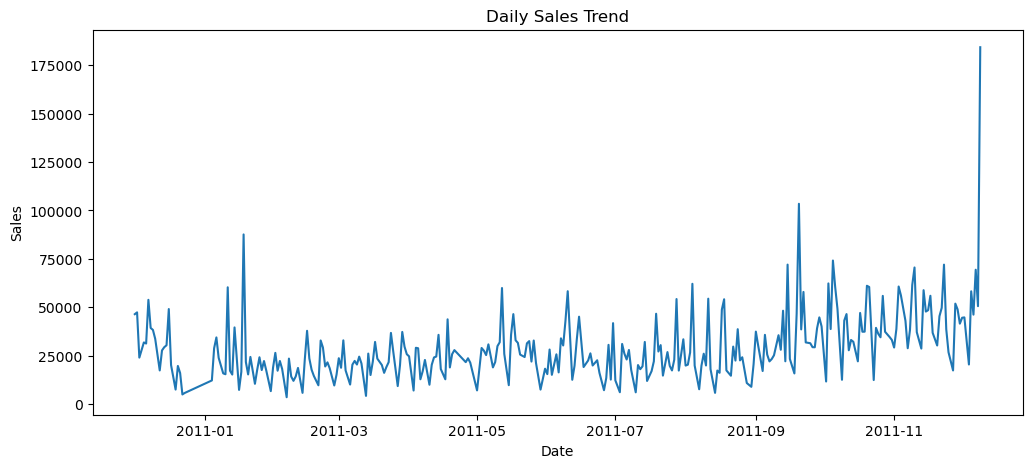

MAE: 15312.326458709276
RMSE: 25092.05274961664


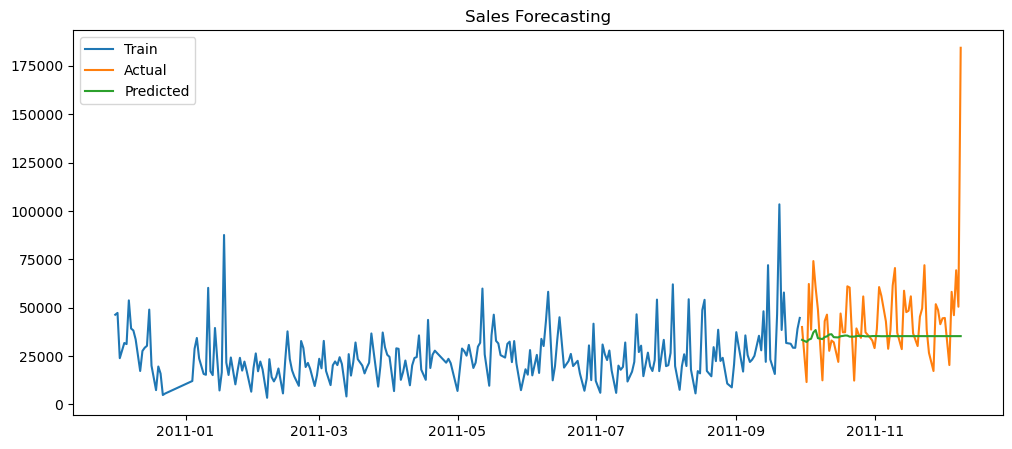

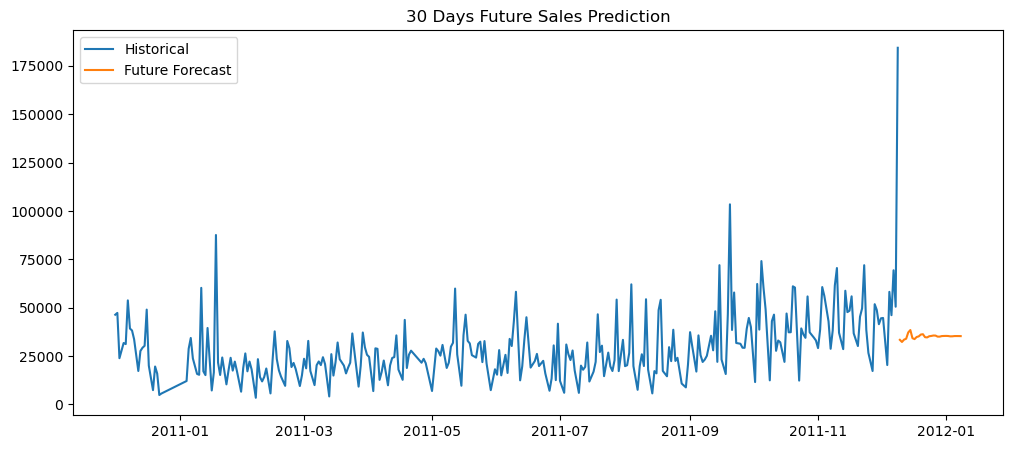

Future Predictions:
244    33396.692499
245    32307.232936
246    33504.699156
247    33959.450900
248    37239.179979
249    38464.258735
250    34254.939248
251    33782.416919
252    34866.402293
253    35190.860129
254    36147.964483
255    36303.294364
256    34775.051120
257    34653.802697
258    35260.846301
259    35413.156333
260    35637.683188
261    35597.698963
262    35063.834791
263    35060.358992
264    35347.093031
265    35402.098701
266    35429.110810
267    35385.150892
268    35208.297435
269    35227.436065
270    35350.068977
271    35364.475385
272    35352.499834
273    35328.849663
Name: predicted_mean, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
file_path = r"C:\Users\ganes\Downloads\online+retail\Online Retail.xlsx"
df = pd.read_excel(file_path)
print(df.head())
print(df.info())
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df_daily = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()
df_daily = pd.DataFrame(df_daily)
df_daily.index = pd.to_datetime(df_daily.index)
print(df_daily.head())
plt.figure(figsize=(12,5))
plt.plot(df_daily)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
train_size = int(len(df_daily) * 0.8)
train, test = df_daily[:train_size], df_daily[train_size:]
model = ARIMA(train, order=(5,1,0)) 
model_fit = model.fit()
predictions = model_fit.forecast(steps=len(test))
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print("MAE:", mae)
print("RMSE:", rmse)
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted")
plt.legend()
plt.title("Sales Forecasting")
plt.show()
future_steps = 30
future_forecast = model_fit.forecast(steps=future_steps)
future_dates = pd.date_range(start=df_daily.index[-1], periods=future_steps+1)[1:]
plt.figure(figsize=(12,5))
plt.plot(df_daily, label="Historical")
plt.plot(future_dates, future_forecast, label="Future Forecast")
plt.legend()
plt.title("30 Days Future Sales Prediction")
plt.show()

print("Future Predictions:")
print(future_forecast)

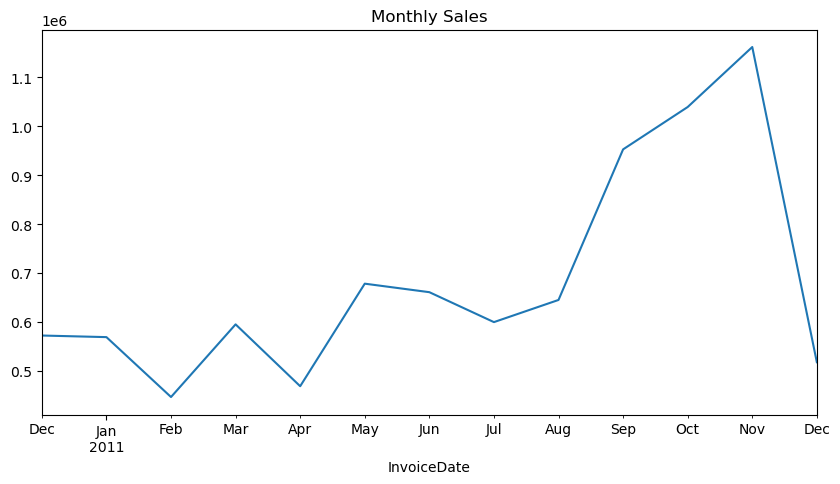

In [3]:
df_monthly = df.resample('M', on='InvoiceDate')['TotalPrice'].sum()
df_monthly.plot(figsize=(10,5), title="Monthly Sales")
plt.show()

In [4]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_countries)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64


In [5]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64
